In [1]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('customer.csv')
df.sample(5)

,age,gender,review,education,purchased
18,19,Male,Good,School,No
33,89,Female,Good,PG,Yes
7,60,Female,Poor,School,Yes
40,39,Male,Good,School,No
46,64,Female,Poor,PG,No


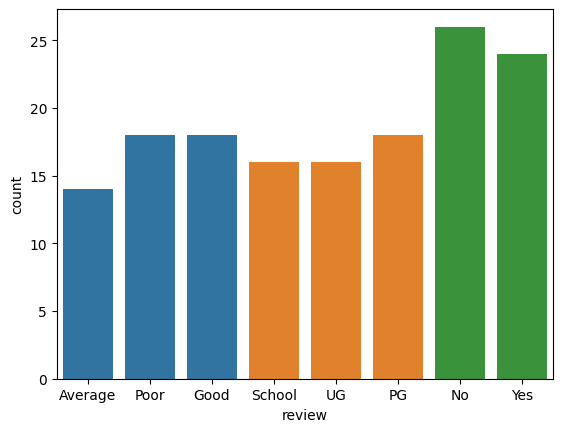

In [14]:
# checking how the data is 
sns.countplot(x=df['review'])
sns.countplot(x=df['education'])
sns.countplot(x=df['purchased'])
plt.show()

In [15]:
# we can see how many categories are there
# removing age and gender because gender need one hot encoding which we will study later
df = df.iloc[:,2:]

In [16]:
df.head()

,review,education,purchased
0,Average,School,No
1,Poor,UG,No
2,Good,PG,No
3,Good,PG,No
4,Average,UG,No


In [33]:
# doing train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df['purchased'],test_size=0.3,random_state=0)

In [34]:
# importing ordinal encoder 
from sklearn.preprocessing import OrdinalEncoder

In [35]:
oe = OrdinalEncoder(categories=[['Poor','Average','Good'],['School','UG','PG']])

In [36]:
oe.fit(x_train)
x_train_ordinal = oe.transform(x_train)
x_test_ordinal = oe.transform(x_test)

In [37]:
# converting back into data frame to clearly see 
x_train_ordinal = pd.DataFrame(x_train_ordinal,columns=x_train.columns)
x_test_ordinal = pd.DataFrame(x_test_ordinal,columns=x_test.columns)

In [38]:
x_train_ordinal.head()

,review,education
0,0.0,0.0
1,0.0,2.0
2,0.0,2.0
3,2.0,1.0
4,1.0,1.0


In [51]:
# now we will perform label encoding on output collumns (note label encoing is done on numerical columns)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)
y_train_label = le.transform(y_train)
y_test_label = le.transform(y_test)

In [50]:
# we can see that we encoded all categorical values to numerical form 